In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


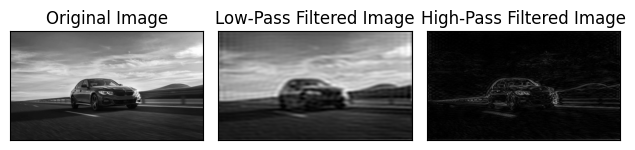

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/opencv/bmw1.jpg', 0) # Read as grayscale

#Perform Discrete Fourier Transform (DFT)
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

#Shift the Zero-Frequency Component to the Center:
dft_shift = np.fft.fftshift(dft)

#Low-Pass Filter (LPF): A circular mask with white inside (allowing low frequencies) and black outside (blocking high frequencies).
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Create a blank mask
mask_lpf = np.zeros((rows, cols, 2), np.uint8)

# Draw a white circle (low-pass filter)
radius_lpf = 30 # Adjust this value for different cutoff frequencies       radius_lpf Radius of the circle = cutoff frequency (e.g., 30 pixels)
cv2.circle(mask_lpf, (ccol, crow), radius_lpf, (1, 1), -1)    #(ccol, crow) Center of the frequency domain (col, row) — center of the image
#(1, 1) Color of the circle. (1, 1) means white in a 2-channel mask (real + imaginary)
#-1 Thickness = -1 means fill the circle (not just border)


#High-Pass Filter (HPF): The inverse of the LPF mask, with black inside (blocking low frequencies) and white outside (allowing high frequencies).
# Create a blank mask
mask_hpf = np.ones((rows, cols, 2), np.uint8)

# Draw a black circle (high-pass filter)
radius_hpf = 30 # Adjust this value
cv2.circle(mask_hpf, (ccol, crow), radius_hpf, (0, 0), -1)

#Apply the Mask to the Shifted DFT:

# For Low-Pass Filter
fshift_lpf = dft_shift * mask_lpf

# For High-Pass Filter
fshift_hpf = dft_shift * mask_hpf

#Perform Inverse Shift and Inverse DFT.

# For Low-Pass Filter
f_ishift_lpf = np.fft.ifftshift(fshift_lpf)
img_back_lpf = cv2.idft(f_ishift_lpf)
img_back_lpf = cv2.magnitude(img_back_lpf[:, :, 0], img_back_lpf[:, :, 1])

# For High-Pass Filter
f_ishift_hpf = np.fft.ifftshift(fshift_hpf)
img_back_hpf = cv2.idft(f_ishift_hpf)
img_back_hpf = cv2.magnitude(img_back_hpf[:, :, 0], img_back_hpf[:, :, 1])

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(img_back_lpf, cmap='gray')
plt.title('Low-Pass Filtered Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(img_back_hpf, cmap='gray')
plt.title('High-Pass Filtered Image'), plt.xticks([]), plt.yticks([])

plt.tight_layout() # Add this line to increase spacing
plt.show()